<a href="https://colab.research.google.com/github/orenlevis/HiggsPeak_StatsProject/blob/main/Data_Extraction_General.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Instructions for this notebook**

The purpose of this notebook is to import the raw data CERN opendata files, apply selection criteria to filter Higgs event candidates, and export the filtered invariant mass file.

The raw files (~10Gb) are uploaded in a public Google drive folder, and can be accessed through `!gdown`.


Even though this ensures reproducibility, we reccommend you examine the code output without downloading and filtering the files, which takes about 10 minutes to run. The final csv file can be found in `data/Combined_mass_data_final.csv` inside the repo.


In [1]:
!pip install uproot
!pip install awkward_pandas
!pip install vector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.4/395.4 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 7.4 MB/s eta 0:00:00


In [8]:
# if executed, will download about 10gb of data!
# we reccommend only using the combined data file at the end of this notebook

!pip install gdown
!gdown --folder https://drive.google.com/drive/folders/1XXFkaOMLtb6zQpkaOcCHnT1BmveH0A99?usp=sharing

Retrieving folder contents
Processing file 1VJypYgYEe2UUY5lHLSFt4ftciGvi5sGY Combined_mass_data_final.csv
Processing file 1meaXTGF6IpNRWBJt_9G2zhoZyw73kEaM Run2012B_DoubleElectron.root
Processing file 1NMf2T7OCXLkDkDP9QDpczk_Y4HlYD-9d Run2012B_DoubleMuParked.root
Processing file 1Mk4mAWTP7aPsp16T1P66nNyhm7Po3BT8 Run2012C_DoubleElectron.root
Processing file 1SVK0t9kdeOdwuZ0_FiPRI0gvbJKdM24V Run2012C_DoubleMuParked.root
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1VJypYgYEe2UUY5lHLSFt4ftciGvi5sGY
To: /content/true_rootfiles/Combined_mass_data_final.csv
100% 97.6k/97.6k [00:00<00:00, 62.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1meaXTGF6IpNRWBJt_9G2zhoZyw73kEaM
From (redirected): https://drive.google.com/uc?id=1meaXTGF6IpNRWBJt_9G2zhoZyw73kEaM&confirm=t&uuid=b9d0bcb1-d21e-400f-9442-92b62d219eda
To: /content/true_rootfiles/Run2012B_DoubleElectron.root

In [3]:
import uproot
import awkward as ak
import numpy as np
import vector

# Register awkward to use .mass, .pt, etc., on awkward arrays
vector.register_awkward()

def process_file(file_path, dataset_type="muon"):
    """
    dataset_type: "muon" or "electron".
    Used to prevent double-counting 2e2mu events across datasets.
    """
    output_masses = []

    def get_safe_pt(sorted_pts, index_to_access):
        padded_pts = ak.pad_none(sorted_pts, index_to_access + 1, axis=1, clip=True)
        return ak.fill_none(padded_pts[:, index_to_access], -1.0)

    for chunk in uproot.iterate(f"{file_path}:Events", step_size="100 MB"):
        # Muon Selection
        mu = ak.zip({
            "pt": chunk.Muon_pt, "eta": chunk.Muon_eta, "phi": chunk.Muon_phi, "mass": chunk.Muon_mass,
            "charge": chunk.Muon_charge, "dxy": chunk.Muon_dxy, "dz": chunk.Muon_dz,
            "dxyErr": chunk.Muon_dxyErr, "dzErr": chunk.Muon_dzErr, "pfRelIso04_all": chunk.Muon_pfRelIso04_all
        })
        mu_sip3d = np.sqrt(mu.dxy**2 + mu.dz**2) / np.sqrt(mu.dxyErr**2 + mu.dzErr**2)
        mu_mask = (mu.pt > 5) & (np.abs(mu.eta) < 2.4) & (mu.pfRelIso04_all < 0.40) & (mu_sip3d < 4) & (np.abs(mu.dxy) < 0.5) & (np.abs(mu.dz) < 1.0)
        good_mu = mu[mu_mask]

        # Electron Selection
        el = ak.zip({
            "pt": chunk.Electron_pt, "eta": chunk.Electron_eta, "phi": chunk.Electron_phi, "mass": chunk.Electron_mass,
            "charge": chunk.Electron_charge, "dxy": chunk.Electron_dxy, "dz": chunk.Electron_dz,
            "dxyErr": chunk.Electron_dxyErr, "dzErr": chunk.Electron_dzErr, "pfRelIso03_all": chunk.Electron_pfRelIso03_all
        })
        el_sip3d = np.sqrt(el.dxy**2 + el.dz**2) / np.sqrt(el.dxyErr**2 + el.dzErr**2)
        el_mask = (el.pt > 7) & (np.abs(el.eta) < 2.5) & (el.pfRelIso03_all < 0.40) & (el_sip3d < 4) & (np.abs(el.dxy) < 0.5) & (np.abs(el.dz) < 1.0)
        good_el = el[el_mask]

        # Define primary channel masks
        is_4mu = (ak.num(good_mu) == 4) & (ak.num(good_el) == 0) & (ak.sum(good_mu.charge, axis=1) == 0)
        is_4e = (ak.num(good_mu) == 0) & (ak.num(good_el) == 4) & (ak.sum(good_el.charge, axis=1) == 0)
        is_2e2mu = (ak.num(good_mu) == 2) & (ak.num(good_el) == 2) & (ak.sum(good_mu.charge, axis=1) == 0) & (ak.sum(good_el.charge, axis=1) == 0)

        # OVERLAP REMOVAL: Only take 2e2mu from the Muon dataset
        if dataset_type == "muon":
            event_mask = is_4mu | is_2e2mu
        else:
            event_mask = is_4e

        if not ak.any(event_mask): continue

        leptons_mu = good_mu[event_mask]
        leptons_el = good_el[event_mask]
        is_4mu_em = is_4mu[event_mask]
        is_4e_em = is_4e[event_mask]
        is_2e2mu_em = is_2e2mu[event_mask]

        # Pt thresholds
        mu_pt_sorted = ak.sort(leptons_mu.pt, ascending=False)
        el_pt_sorted = ak.sort(leptons_el.pt, ascending=False)
        mu_lead_pt, mu_sublead_pt = get_safe_pt(mu_pt_sorted, 0), get_safe_pt(mu_pt_sorted, 1)
        el_lead_pt, el_sublead_pt = get_safe_pt(el_pt_sorted, 0), get_safe_pt(el_pt_sorted, 1)

        pass_pt = (ak.where(is_4mu_em, (mu_lead_pt > 20) & (mu_sublead_pt > 10), False) |
                  ak.where(is_4e_em, (el_lead_pt > 20) & (el_sublead_pt > 10), False) |
                  ak.where(is_2e2mu_em, ((mu_lead_pt > 20) & (mu_sublead_pt > 10)) | ((el_lead_pt > 20) & (el_sublead_pt > 10)), False))

        p4_mu = ak.zip({"pt": leptons_mu.pt, "eta": leptons_mu.eta, "phi": leptons_mu.phi, "mass": leptons_mu.mass, "charge": leptons_mu.charge}, with_name="Momentum4D")
        p4_el = ak.zip({"pt": leptons_el.pt, "eta": leptons_el.eta, "phi": leptons_el.phi, "mass": leptons_el.mass, "charge": leptons_el.charge}, with_name="Momentum4D")
        z_pdg = 91.1876

        # Z reconstruction logic (z1, z2)
        z1 = ak.full_like(is_4mu_em, np.nan, dtype=float)
        z2 = ak.full_like(is_4mu_em, np.nan, dtype=float)

        if ak.any(is_2e2mu_em):
            m_mu = (p4_mu[is_2e2mu_em, 0] + p4_mu[is_2e2mu_em, 1]).mass
            m_el = (p4_el[is_2e2mu_em, 0] + p4_el[is_2e2mu_em, 1]).mass
            z1_m = ak.where(np.abs(m_mu - z_pdg) < np.abs(m_el - z_pdg), m_mu, m_el)
            z2_m = ak.where(np.abs(m_mu - z_pdg) < np.abs(m_el - z_pdg), m_el, m_mu)
            z1 = ak.where(is_2e2mu_em, ak.pad_none(z1_m, len(is_2e2mu_em), axis=0, clip=True), z1)
            z2 = ak.where(is_2e2mu_em, ak.pad_none(z2_m, len(is_2e2mu_em), axis=0, clip=True), z2)

        is_4l_em = is_4mu_em | is_4e_em
        if ak.any(is_4l_em):
            p4_s = ak.where(is_4mu_em, p4_mu, p4_el)[is_4l_em]
            m01, m23, m02, m13, m03, m12 = (p4_s[:,0]+p4_s[:,1]).mass, (p4_s[:,2]+p4_s[:,3]).mass, (p4_s[:,0]+p4_s[:,2]).mass, (p4_s[:,1]+p4_s[:,3]).mass, (p4_s[:,0]+p4_s[:,3]).mass, (p4_s[:,1]+p4_s[:,2]).mass
            os_A, os_B, os_C = p4_s[:,0].charge != p4_s[:,1].charge, p4_s[:,0].charge != p4_s[:,2].charge, p4_s[:,0].charge != p4_s[:,3].charge
            dA1, dA2, dB1, dB2, dC1, dC2 = ak.where(os_A, np.abs(m01-z_pdg), 9999), ak.where(os_A, np.abs(m23-z_pdg), 9999), ak.where(os_B, np.abs(m02-z_pdg), 9999), ak.where(os_B, np.abs(m13-z_pdg), 9999), ak.where(os_C, np.abs(m03-z_pdg), 9999), ak.where(os_C, np.abs(m12-z_pdg), 9999)
            min_d = np.minimum.reduce([dA1, dA2, dB1, dB2, dC1, dC2])
            z1_s = ak.where(min_d == dA1, m01, ak.where(min_d == dA2, m23, ak.where(min_d == dB1, m02, ak.where(min_d == dB2, m13, ak.where(min_d == dC1, m03, m12)))))
            z2_s = ak.where(min_d == dA1, m23, ak.where(min_d == dA2, m01, ak.where(min_d == dB1, m13, ak.where(min_d == dB2, m02, ak.where(min_d == dC1, m12, m03)))))
            z1 = ak.where(is_4l_em, ak.pad_none(z1_s, len(is_4l_em), axis=0, clip=True), z1)
            z2 = ak.where(is_4l_em, ak.pad_none(z2_s, len(is_4l_em), axis=0, clip=True), z2)

        z_mass_cut = (z1 > 40) & (z1 < 120) & (z2 > 12) & (z2 < 120) #numbers from Cern report
        final_mask = pass_pt & z_mass_cut
        masses = (ak.sum(p4_mu, axis=1) + ak.sum(p4_el, axis=1)).mass[final_mask]
        output_masses.append(ak.to_numpy(masses))

    return np.concatenate(output_masses)

### 4-Lepton Selection Criteria Analysis

For the invariant mass reconstruction, the following filters were applied to the CMS Open Data:

#### 1. Lepton Quality & Identification (Object Selection)
To ensure we only use well-reconstructed leptons, we apply several 'Good Lepton' masks:
*   **Transverse Momentum ($p_T$):** Muons must have $p_T > 5$ GeV and Electrons $p_T > 7$ GeV. This removes low-energy 'noise' particles.
*   **Eta ($η$):** Restricted to $η < 2.4$ (muons) and $2.5$ (electrons) to ensure the particles are within the sensitive tracking volume of the detector.
*   **Isolation (`pfRelIso`):** Set to $< 0.40$. This ensures the lepton is 'isolated' and not part of a jet, which is a key signature of electroweak bosons.
*   **Impact Parameter ($d_{xy}$, $d_z$):** Particles must originate close to the primary interaction vertex ($|d_{xy}| < 0.5$, $|d_z| < 1.0$) to reduce background from cosmic rays or secondary interactions.
*   **SIP3D (Significance):** The 3D Impact Parameter significance must be $< 4$. This is a strict cut to ensure the leptons come from the prompt decay of a Z or Higgs boson.

#### 2. Event Selection (The 4-Lepton Requirement)
We look for three specific 'channels' that could come from a $H → ZZ^* → 4ℓ$ decay:
*   **4-Muon (4̴):** Exactly 4 good muons, 0 good electrons.
*   **4-Electron (4e):** Exactly 4 good electrons, 0 good muons.
*   **2-Electron 2-Muon (2e2̴):** Exactly 2 of each.
*   **Charge Conservation:** The sum of the charges of the four leptons must be **0** (neutrality).

#### 3. Z-Boson Reconstruction Logic
The four leptons are paired into two Z candidates ($Z_1$ and $Z_2$):
*   **Z1 Selection:** The pair with an invariant mass closest to the nominal Z-boson mass (91.18 GeV).
*   **Z1 Mass Cut:** $40 < m_{Z1} < 120$ GeV (The 'on-shell' Z).
*   **Z2 Mass Cut:** $12 < m_{Z2} < 120$ GeV (The 'off-shell' Z, which is lighter in Higgs decays).

#### 4. Trigger Emulation (Pt Thresholds)
To mimic the hardware trigger conditions, we require:
*   The leading (fastest) lepton to have $p_T > 20$ GeV.
*   The sub-leading lepton to have $p_T > 10$ GeV.

In [11]:
# get individual raw data files from the drive folder

base_path = "true_rootfiles/"

Run2012B_muon_m4l = process_file(
    base_path + "Run2012B_DoubleMuParked.root",
    dataset_type="muon"
)
print(f"Done Muon B! Found {len(Run2012B_muon_m4l)} total candidates.")

Run2012C_muon_m4l = process_file(
    base_path + "Run2012C_DoubleMuParked.root",
    dataset_type="muon"
)
print(f"Done Muon C! Found {len(Run2012C_muon_m4l)} total candidates.")

Run2012B_electron_m4l = process_file(
    base_path + "Run2012B_DoubleElectron.root",
    dataset_type="electron"
)
print(f"Done Electron B! Found {len(Run2012B_electron_m4l)} total candidates.")

Run2012C_electron_m4l = process_file(
    base_path + "Run2012C_DoubleElectron.root",
    dataset_type="electron"
)
print(f"Done Electron C! Found {len(Run2012C_electron_m4l)} total candidates.")

Done Muon B! Found 1155 total candidates.
Done Muon C! Found 1734 total candidates.
Done Electron B! Found 3169 total candidates.
Done Electron C! Found 4931 total candidates.


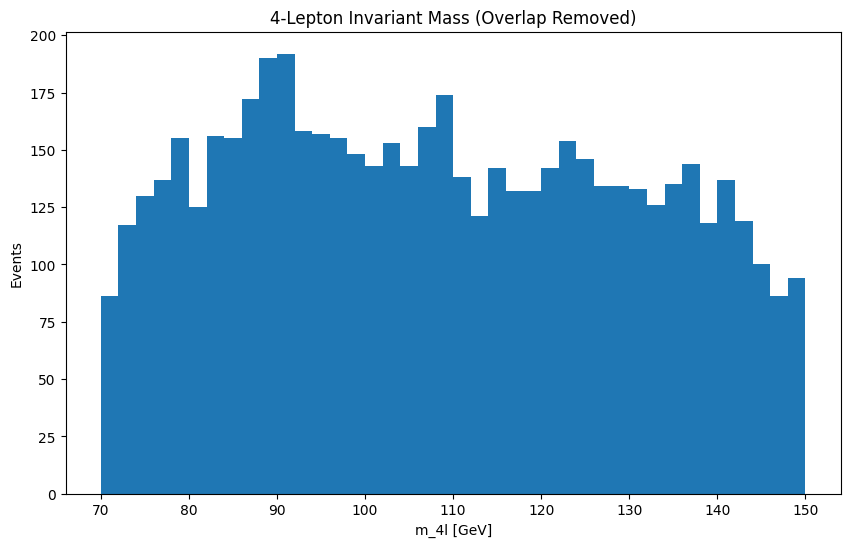

Total unique candidates found: 10989


In [6]:
import matplotlib.pyplot as plt

# Combine the filtered results from all datasets
final_m4l = np.concatenate([Run2012B_muon_m4l, Run2012C_muon_m4l, Run2012B_electron_m4l, Run2012C_electron_m4l])

# Plot the invariant mass distribution
plt.figure(figsize=(10, 6))
plt.hist(final_m4l, bins=40, range=(70, 150))
plt.xlabel('m_4l [GeV]')
plt.ylabel('Events')
plt.title('4-Lepton Invariant Mass (Overlap Removed)')
plt.show()

print(f"Total unique candidates found: {len(final_m4l)}")

Note here that out of millions of data points from the 4 datasets, only 11000 unique candidates survived the selection criteria. This is expected, and in fact the official CERN reports have even less events in each bin owing to stricter filters we do not have access to.

In [7]:
# export combined filtered data as a .csv

import pandas as pd
pd.Series(final_m4l, name='m_4l').to_csv('Combined_mass_data_final.csv', index=False)